# Algoritmos clássicos de Machine Learning com scikit-learn

## comparação de modelos e tuning de hiperparâmetros

### Objetivos de aprendizagem


- diferenciar problemas de **classificação** e **regressão**;
- compreender o fluxo básico de Machine Learning clássico;
- treinar diferentes algoritmos usando `scikit-learn`;
- comparar modelos usando métricas adequadas;
- entender diferenças conceituais entre algoritmos;
- identificar sinais de overfitting e underfitting;
- aplicar validação cruzada;
- usar `GridSearchCV` e `RandomizedSearchCV`;
- interpretar resultados de busca de hiperparâmetros;
- construir uma análise comparativa entre modelos.


## 1. Visão geral de Machine Learning clássico

Machine Learning clássico trabalha com algoritmos que aprendem padrões a partir de dados estruturados.

Em geral:

```text
X → atributos/features
y → alvo/target
```

Exemplos:

| Problema | Entrada X | Saída y | Tipo |
|---|---|---|---|
| Diagnóstico médico | medidas clínicas | benigno/maligno | Classificação |
| Preço de imóvel | área, localização, quartos | preço | Regressão |
| Segmentação de clientes | perfil de compra | grupo | Agrupamento |

Nesta aula, vamos focar em:

- **classificação**
- **regressão**
- **comparação entre algoritmos**
- **tuning de hiperparâmetros**


## 2. Bibliotecas utilizadas


In [246]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer, fetch_california_housing
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV,
    RandomizedSearchCV
)

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

import warnings
warnings.filterwarnings("ignore")


# PARTE 1 — CLASSIFICAÇÃO

## 3. O que é classificação?

Classificação é uma tarefa supervisionada em que o modelo aprende a prever uma **categoria**.

Exemplos:

- spam ou não spam;
- doente ou saudável;
- aprovado ou reprovado;
- classe de uma imagem;
- tipo de cliente.

Nesta parte, usaremos o dataset `breast_cancer`, disponível no próprio `scikit-learn`.

O objetivo é prever se um tumor é **maligno** ou **benigno** com base em medidas extraídas de imagens médicas.


## 4. Carregando o dataset de classificação


In [247]:
data = load_breast_cancer()

X = data.data
y = data.target

feature_names = data.feature_names
target_names = data.target_names

df = pd.DataFrame(X, columns=feature_names)
df["target"] = y

print("Formato de X:", X.shape)
print("Formato de y:", y.shape)
print("Classes:", target_names)

df.head()


Formato de X: (569, 30)
Formato de y: (569,)
Classes: ['malignant' 'benign']


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


## 5. Separando treino e teste

O conjunto de treino é usado para ajustar o modelo.  
O conjunto de teste é usado para avaliar o desempenho em dados não vistos.

A separação evita avaliar o modelo nos mesmos dados usados para treinamento.


In [248]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)


Treino: (455, 30)
Teste: (114, 30)


## 6. Função auxiliar para avaliação de classificação


In [249]:
def avaliar_classificacao(nome_modelo, modelo, X_train, X_test, y_train, y_test):
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"Modelo: {nome_modelo}")
    print(f"Acurácia: {acc:.4f}")
    print(f"Precisão: {prec:.4f}")
    print(f"Recall: {rec:.4f}")
    print(f"F1-score: {f1:.4f}")
    print("\nRelatório de classificação:")
    print(classification_report(y_test, y_pred, target_names=target_names))

    return {
        "Modelo": nome_modelo,
        "Acurácia": acc,
        "Precisão": prec,
        "Recall": rec,
        "F1-score": f1
    }, y_pred


## 7. Modelo 1 — Regressão Logística

Apesar do nome, a Regressão Logística é usada para **classificação**.

### Características

- modelo linear;
- interpretável;
- funciona bem como baseline;
- sensível à escala dos dados;
- pode ter desempenho limitado em padrões muito não lineares.


In [250]:
log_model = Pipeline([("scaler", StandardScaler()), ("model", LogisticRegression(max_iter=1000))])

resultado_log, y_pred_log = avaliar_classificacao(
    "Regressão Logística",
    log_model,
    X_train,
    X_test,
    y_train,
    y_test
)


Modelo: Regressão Logística
Acurácia: 0.9825
Precisão: 0.9861
Recall: 0.9861
F1-score: 0.9861

Relatório de classificação:
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



## 8. Modelo 2 — KNN

O KNN classifica uma amostra com base nos vizinhos mais próximos.

### Características

- simples;
- não aprende uma função explícita;
- sensível à escala;
- pode ser lento na predição;
- depende fortemente do valor de `k`.


In [251]:
knn_model = Pipeline([("scaler", StandardScaler()), ("model", KNeighborsClassifier(n_neighbors=5))])

resultado_knn, y_pred_knn = avaliar_classificacao(
    "KNN",
    knn_model,
    X_train,
    X_test,
    y_train,
    y_test
)


Modelo: KNN
Acurácia: 0.9561
Precisão: 0.9589
Recall: 0.9722
F1-score: 0.9655

Relatório de classificação:
              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



## 9. Modelo 3 — Árvore de Decisão

A Árvore de Decisão cria regras do tipo `se atributo <= valor`.

### Características

- fácil de interpretar;
- não exige normalização;
- pode capturar relações não lineares;
- propensa a overfitting.


In [252]:
tree_model = DecisionTreeClassifier(random_state=42)

resultado_tree, y_pred_tree = avaliar_classificacao(
    "Árvore de Decisão",
    tree_model,
    X_train,
    X_test,
    y_train,
    y_test
)


Modelo: Árvore de Decisão
Acurácia: 0.9123
Precisão: 0.9559
Recall: 0.9028
F1-score: 0.9286

Relatório de classificação:
              precision    recall  f1-score   support

   malignant       0.85      0.93      0.89        42
      benign       0.96      0.90      0.93        72

    accuracy                           0.91       114
   macro avg       0.90      0.92      0.91       114
weighted avg       0.92      0.91      0.91       114



## 11. Modelo 4 — Random Forest

Random Forest é um ensemble de árvores.

### Características

- mais robusto que uma árvore isolada;
- reduz overfitting;
- geralmente tem bom desempenho;
- menos interpretável que uma árvore única;
- não exige normalização.


In [253]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

resultado_rf, y_pred_rf = avaliar_classificacao(
    "Random Forest",
    rf_model,
    X_train,
    X_test,
    y_train,
    y_test
)


Modelo: Random Forest
Acurácia: 0.9561
Precisão: 0.9589
Recall: 0.9722
F1-score: 0.9655

Relatório de classificação:
              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



## 12. Modelo 5 — SVM

SVM busca uma fronteira de separação com maior margem entre classes.

### Características

- pode funcionar bem em datasets pequenos e médios;
- sensível à escala;
- pode usar kernels para padrões não lineares;
- pode ser custoso em datasets grandes.


In [254]:
svm_model = Pipeline([("scaler", StandardScaler()), ("model", SVC(kernel="rbf", C=1.0))])

resultado_svm, y_pred_svm = avaliar_classificacao(
    "SVM",
    svm_model,
    X_train,
    X_test,
    y_train,
    y_test
)


Modelo: SVM
Acurácia: 0.9825
Precisão: 0.9861
Recall: 0.9861
F1-score: 0.9861

Relatório de classificação:
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



## 13. Modelo 6 — Naive Bayes

Naive Bayes é baseado no Teorema de Bayes e assume independência entre atributos.

### Características

- muito rápido;
- simples;
- bom para texto e problemas probabilísticos;
- a suposição de independência pode ser irrealista.


In [255]:
nb_model = GaussianNB()

resultado_nb, y_pred_nb = avaliar_classificacao(
    "Naive Bayes",
    nb_model,
    X_train,
    X_test,
    y_train,
    y_test
)


Modelo: Naive Bayes
Acurácia: 0.9386
Precisão: 0.9452
Recall: 0.9583
F1-score: 0.9517

Relatório de classificação:
              precision    recall  f1-score   support

   malignant       0.93      0.90      0.92        42
      benign       0.95      0.96      0.95        72

    accuracy                           0.94       114
   macro avg       0.94      0.93      0.93       114
weighted avg       0.94      0.94      0.94       114



## 10. Visualizando uma Árvore de Decisão


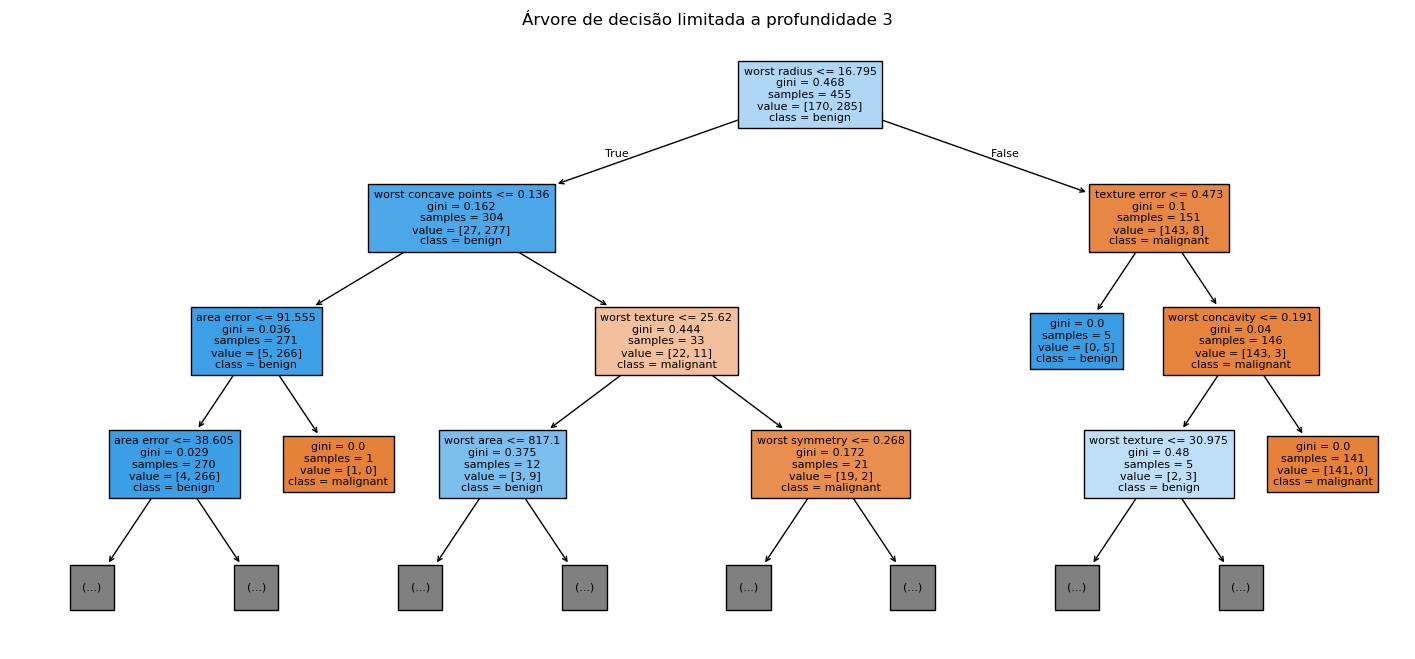

In [256]:
plt.figure(figsize=(18, 8))
plot_tree(
    tree_model,
    feature_names=feature_names,
    class_names=target_names,
    filled=True,
    max_depth=3,
    fontsize=8
)
plt.title("Árvore de decisão limitada a profundidade 3")
plt.show()


## 14. Comparação entre modelos de classificação


In [257]:
resultados_classificacao = pd.DataFrame([
    resultado_log,
    resultado_knn,
    resultado_tree,
    resultado_rf,
    resultado_svm,
    resultado_nb
])

resultados_classificacao.sort_values("F1-score", ascending=False)


,Modelo,Acurácia,Precisão,Recall,F1-score
0,Regressão Logística,0.982456,0.986111,0.986111,0.986111
4,SVM,0.982456,0.986111,0.986111,0.986111
1,KNN,0.956140,0.958904,0.972222,0.965517
3,Random Forest,0.956140,0.958904,0.972222,0.965517
5,Naive Bayes,0.938596,0.945205,0.958333,0.951724
2,Árvore de Decisão,0.912281,0.955882,0.902778,0.928571


## 15. Matriz de confusão

A matriz de confusão mostra:

- linhas: classe real;
- colunas: classe prevista;
- diagonal principal: acertos;
- fora da diagonal: erros.


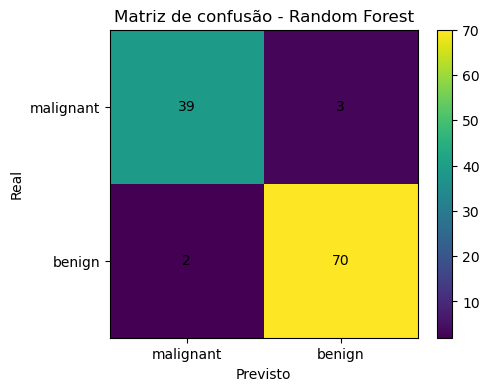

In [258]:
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.title("Matriz de confusão - Random Forest")
plt.xlabel("Previsto")
plt.ylabel("Real")
plt.xticks([0, 1], target_names)
plt.yticks([0, 1], target_names)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.show()


## 16. Diferenças conceituais entre algoritmos de classificação

| Algoritmo | Tipo | Precisa escalar? | Interpretável? | Risco de overfitting |
|---|---|---|---|---|
| Regressão Logística | Linear | Sim | Médio/alto | Baixo/médio |
| KNN | Distância | Sim | Baixo | Depende de k |
| Árvore | Regras | Não | Alto | Alto |
| Random Forest | Ensemble | Não | Médio/baixo | Médio/baixo |
| SVM | Margem/kernel | Sim | Baixo | Médio |
| Naive Bayes | Probabilístico | Não obrigatoriamente | Médio | Baixo |


# PARTE 2 — REGRESSÃO

## 17. O que é regressão?

Regressão é uma tarefa supervisionada em que o modelo prevê um **valor numérico contínuo**.

Exemplos:

- preço de casas;
- consumo de energia;
- temperatura;
- tempo de entrega;
- faturamento.

Nesta parte, usaremos o dataset `California Housing`.


## 18. Carregando o dataset de regressão


In [259]:
housing = fetch_california_housing()

X_reg = housing.data
y_reg = housing.target

reg_feature_names = housing.feature_names

df_reg = pd.DataFrame(X_reg, columns=reg_feature_names)
df_reg["target"] = y_reg

print("Formato de X:", X_reg.shape)
print("Formato de y:", y_reg.shape)

df_reg.head()


Formato de X: (20640, 8)
Formato de y: (20640,)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## 19. Separando treino e teste para regressão


In [260]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)

print("Treino:", X_train_reg.shape)
print("Teste:", X_test_reg.shape)


Treino: (16512, 8)
Teste: (4128, 8)


## 20. Função auxiliar para avaliação de regressão

### MAE — Mean Absolute Error

$$
MAE = \frac{1}{n}\sum |y_i - \hat{y}_i|
$$

### MSE — Mean Squared Error

$$
MSE = \frac{1}{n}\sum (y_i - \hat{y}_i)^2
$$

### RMSE — Root Mean Squared Error

$$
RMSE = \sqrt{MSE}
$$

### R² — coeficiente de determinação

Indica a proporção da variância explicada pelo modelo.


In [261]:
def avaliar_regressao(nome_modelo, modelo, X_train, X_test, y_train, y_test):
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    print(f"Modelo: {nome_modelo}")
    print(f"MAE: {mae:.4f}")
    print(f"MSE: {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R²: {r2:.4f}")

    return {
        "Modelo": nome_modelo,
        "MAE": mae,
        "RMSE": rmse,
        "R²": r2
    }, y_pred


## 21. Modelo 1 — Regressão Linear

A Regressão Linear tenta modelar uma relação linear entre atributos e alvo.


In [262]:
lin_model = LinearRegression()

resultado_lin, y_pred_lin = avaliar_regressao(
    "Regressão Linear",
    lin_model,
    X_train_reg,
    X_test_reg,
    y_train_reg,
    y_test_reg
)


Modelo: Regressão Linear
MAE: 0.5332
MSE: 0.5559
RMSE: 0.7456
R²: 0.5758


## 22. Modelo 2 — Ridge Regression

Ridge é uma regressão linear com regularização L2.


In [263]:
ridge_model = Pipeline([("scaler", StandardScaler()), ("model", Ridge(alpha=1.0))])

resultado_ridge, y_pred_ridge = avaliar_regressao(
    "Ridge",
    ridge_model,
    X_train_reg,
    X_test_reg,
    y_train_reg,
    y_test_reg
)


Modelo: Ridge
MAE: 0.5332
MSE: 0.5559
RMSE: 0.7456
R²: 0.5758


## 23. Modelo 3 — KNN Regressor

Prevê um valor com base na média dos vizinhos mais próximos.


In [264]:
knn_reg_model = Pipeline([("scaler", StandardScaler()), ("model", KNeighborsRegressor(n_neighbors=5))])

resultado_knn_reg, y_pred_knn_reg = avaliar_regressao(
    "KNN Regressor",
    knn_reg_model,
    X_train_reg,
    X_test_reg,
    y_train_reg,
    y_test_reg
)


Modelo: KNN Regressor
MAE: 0.4462
MSE: 0.4324
RMSE: 0.6576
R²: 0.6700


## 24. Modelo 4 — Árvore de Decisão para Regressão

Árvores de regressão aprendem regras para prever valores contínuos.


In [265]:
tree_reg_model = DecisionTreeRegressor(random_state=42)

resultado_tree_reg, y_pred_tree_reg = avaliar_regressao(
    "Árvore de Regressão",
    tree_reg_model,
    X_train_reg,
    X_test_reg,
    y_train_reg,
    y_test_reg
)


Modelo: Árvore de Regressão
MAE: 0.4547
MSE: 0.4952
RMSE: 0.7037
R²: 0.6221


## 25. Modelo 5 — Random Forest para Regressão

Random Forest Regressor combina várias árvores para reduzir variância.


In [266]:
rf_reg_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

resultado_rf_reg, y_pred_rf_reg = avaliar_regressao(
    "Random Forest Regressor",
    rf_reg_model,
    X_train_reg,
    X_test_reg,
    y_train_reg,
    y_test_reg
)


Modelo: Random Forest Regressor
MAE: 0.3275
MSE: 0.2554
RMSE: 0.5053
R²: 0.8051


## 26. Comparação entre modelos de regressão


In [267]:
resultados_regressao = pd.DataFrame([
    resultado_lin,
    resultado_ridge,
    resultado_knn_reg,
    resultado_tree_reg,
    resultado_rf_reg
])

resultados_regressao.sort_values("RMSE")


,Modelo,MAE,RMSE,R²
4,Random Forest Regressor,0.327543,0.505340,0.805123
2,KNN Regressor,0.446154,0.657588,0.670010
3,Árvore de Regressão,0.454679,0.703729,0.622076
1,Ridge,0.533193,0.745557,0.575816
0,Regressão Linear,0.533200,0.745581,0.575788


## 27. Visualizando valores reais vs previstos


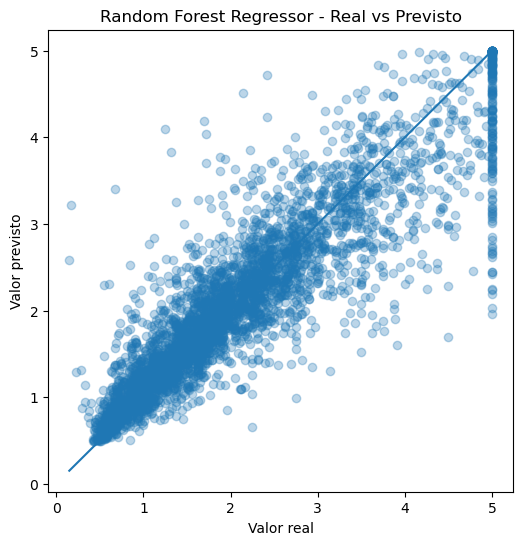

In [268]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test_reg, y_pred_rf_reg, alpha=0.3)
plt.xlabel("Valor real")
plt.ylabel("Valor previsto")
plt.title("Random Forest Regressor - Real vs Previsto")
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()])
plt.show()


# PARTE 3 — OVERFITTING E UNDERFITTING

## 28. Conceitos

### Underfitting
O modelo é simples demais e não aprende bem nem nos dados de treino.

### Overfitting
O modelo aprende demais os detalhes do treino e generaliza mal para teste.

### Boa generalização
O modelo tem bom desempenho tanto no treino quanto no teste.


## 29. Exemplo com profundidade da árvore


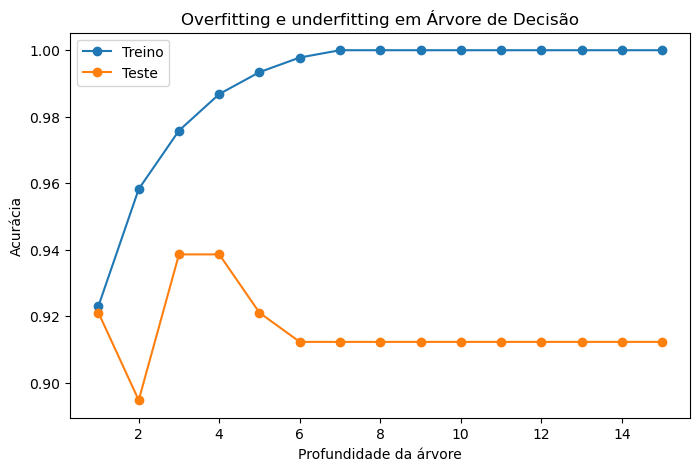

In [269]:
depths = range(1, 16)

train_scores = []
test_scores = []

for depth in depths:
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_scores.append(accuracy_score(y_train, train_pred))
    test_scores.append(accuracy_score(y_test, test_pred))

plt.figure(figsize=(8, 5))
plt.plot(depths, train_scores, marker="o", label="Treino")
plt.plot(depths, test_scores, marker="o", label="Teste")
plt.xlabel("Profundidade da árvore")
plt.ylabel("Acurácia")
plt.title("Overfitting e underfitting em Árvore de Decisão")
plt.legend()
plt.show()


## 30. Interpretação

- Profundidade muito baixa: modelo simples demais.
- Profundidade muito alta: modelo pode memorizar o treino.
- O ponto ideal geralmente está entre simplicidade e complexidade.


# PARTE 4 — VALIDAÇÃO CRUZADA

## 31. O que é Cross-Validation?

A validação cruzada divide os dados em várias partes chamadas *folds*.

Com `cv=5`:

- o dataset é dividido em 5 partes;
- o modelo treina 5 vezes;
- cada vez uma parte diferente é usada como validação;
- o resultado final é a média das avaliações.


In [270]:
rf_cv = RandomForestClassifier(n_estimators=100, random_state=42)

scores = cross_val_score(
    rf_cv,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("Scores:", scores)
print("Média:", scores.mean())
print("Desvio padrão:", scores.std())


Scores: [0.92105263 0.93859649 0.98245614 0.96491228 0.97345133]
Média: 0.9560937742586555
Desvio padrão: 0.02283883380490945


# PARTE 5 — TUNING DE HIPERPARÂMETROS

## 32. Parâmetros vs hiperparâmetros

### Parâmetros
São aprendidos pelo modelo durante o treinamento.

### Hiperparâmetros
São definidos antes do treinamento.

Exemplos:

- `max_depth` em árvores;
- `n_neighbors` no KNN;
- `C` no SVM;
- `n_estimators` no Random Forest.

O tuning busca encontrar boas configurações de hiperparâmetros.


## 33. GridSearchCV

O `GridSearchCV` testa todas as combinações definidas em uma grade de hiperparâmetros.

### Vantagem
- busca exaustiva;
- fácil de entender.

### Desvantagem
- pode ser lento se houver muitas combinações.


In [271]:
param_grid_tree = {
    "max_depth": [2, 3, 4, 5, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

grid_tree = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid_tree,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_tree.fit(X_train, y_train)

print("Melhores parâmetros:")
print(grid_tree.best_params_)

print("Melhor score médio de validação:")
print(grid_tree.best_score_)


Melhores parâmetros:
{'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 5}
Melhor score médio de validação:
0.9517702618506719


## 34. Avaliando o melhor modelo encontrado pelo GridSearchCV


In [272]:
best_tree = grid_tree.best_estimator_
y_pred_best_tree = best_tree.predict(X_test)

print("Acurácia:", accuracy_score(y_test, y_pred_best_tree))
print("F1-score:", f1_score(y_test, y_pred_best_tree))
print(classification_report(y_test, y_pred_best_tree, target_names=target_names))


Acurácia: 0.9210526315789473
F1-score: 0.9361702127659575
              precision    recall  f1-score   support

   malignant       0.87      0.93      0.90        42
      benign       0.96      0.92      0.94        72

    accuracy                           0.92       114
   macro avg       0.91      0.92      0.92       114
weighted avg       0.92      0.92      0.92       114



## 35. Resultados do GridSearch em DataFrame


In [273]:
grid_results = pd.DataFrame(grid_tree.cv_results_)

cols = [
    "mean_test_score",
    "std_test_score",
    "param_max_depth",
    "param_min_samples_split",
    "param_min_samples_leaf",
    "rank_test_score"
]

grid_results[cols].sort_values("rank_test_score").head(10)


,mean_test_score,std_test_score,param_max_depth,param_min_samples_split,param_min_samples_leaf,rank_test_score
28,0.951770,0.014760,5,5,1,1
18,0.951374,0.013970,4,2,1,2
29,0.950415,0.013940,5,10,1,3
19,0.949369,0.014837,4,5,1,4
43,0.947670,0.009740,None,5,4,5
42,0.947670,0.009740,None,2,4,5
34,0.947670,0.009740,5,5,4,5
33,0.947670,0.009740,5,2,4,5
24,0.947383,0.015547,4,2,4,9
25,0.947383,0.015547,4,5,4,9


## 36. GridSearch com Pipeline

Quando o modelo precisa de escalonamento, o ideal é colocar tudo em um `Pipeline`.

Isso evita vazamento de dados durante a validação cruzada.


In [274]:
pipe_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier())
])

param_grid_knn = {
    "model__n_neighbors": [3, 5, 7, 9, 11],
    "model__weights": ["uniform", "distance"],
    "model__metric": ["euclidean", "manhattan"]
}

grid_knn = GridSearchCV(
    estimator=pipe_knn,
    param_grid=param_grid_knn,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_knn.fit(X_train, y_train)

print("Melhores parâmetros:")
print(grid_knn.best_params_)

print("Melhor score:")
print(grid_knn.best_score_)


Melhores parâmetros:
{'model__metric': 'euclidean', 'model__n_neighbors': 7, 'model__weights': 'uniform'}
Melhor score:
0.9774783998014488


## 37. Avaliando o melhor KNN


In [275]:
best_knn = grid_knn.best_estimator_
y_pred_best_knn = best_knn.predict(X_test)

print("Acurácia:", accuracy_score(y_test, y_pred_best_knn))
print("F1-score:", f1_score(y_test, y_pred_best_knn))
print(classification_report(y_test, y_pred_best_knn, target_names=target_names))


Acurácia: 0.9736842105263158
F1-score: 0.9795918367346939
              precision    recall  f1-score   support

   malignant       1.00      0.93      0.96        42
      benign       0.96      1.00      0.98        72

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



## 38. RandomizedSearchCV

O `RandomizedSearchCV` testa combinações aleatórias de hiperparâmetros.

### Vantagem
- mais rápido que GridSearch em espaços grandes;
- útil quando há muitos hiperparâmetros.

### Desvantagem
- não testa todas as combinações.


In [276]:
param_dist_rf = {
    "n_estimators": [50, 100, 200, 300],
    "max_depth": [None, 3, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

random_rf = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_dist_rf,
    n_iter=15,
    cv=5,
    scoring="f1",
    random_state=42,
    n_jobs=-1
)

random_rf.fit(X_train, y_train)

print("Melhores parâmetros:")
print(random_rf.best_params_)

print("Melhor score:")
print(random_rf.best_score_)


Melhores parâmetros:
{'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': None}
Melhor score:
0.9667669294797836


## 39. Avaliando o melhor Random Forest


In [277]:
best_rf = random_rf.best_estimator_
y_pred_best_rf = best_rf.predict(X_test)

print("Acurácia:", accuracy_score(y_test, y_pred_best_rf))
print("F1-score:", f1_score(y_test, y_pred_best_rf))
print(classification_report(y_test, y_pred_best_rf, target_names=target_names))


Acurácia: 0.956140350877193
F1-score: 0.9655172413793104
              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



## 40. Comparação final: modelos padrão vs modelos tunados


In [278]:
comparacao_final = pd.DataFrame([
    {
        "Modelo": "Decision Tree padrão",
        "Acurácia": accuracy_score(y_test, y_pred_tree),
        "F1-score": f1_score(y_test, y_pred_tree)
    },
    {
        "Modelo": "Decision Tree tunada",
        "Acurácia": accuracy_score(y_test, y_pred_best_tree),
        "F1-score": f1_score(y_test, y_pred_best_tree)
    },
    {
        "Modelo": "KNN padrão",
        "Acurácia": accuracy_score(y_test, y_pred_knn),
        "F1-score": f1_score(y_test, y_pred_knn)
    },
    {
        "Modelo": "KNN tunado",
        "Acurácia": accuracy_score(y_test, y_pred_best_knn),
        "F1-score": f1_score(y_test, y_pred_best_knn)
    },
    {
        "Modelo": "Random Forest padrão",
        "Acurácia": accuracy_score(y_test, y_pred_rf),
        "F1-score": f1_score(y_test, y_pred_rf)
    },
    {
        "Modelo": "Random Forest tunado",
        "Acurácia": accuracy_score(y_test, y_pred_best_rf),
        "F1-score": f1_score(y_test, y_pred_best_rf)
    }
])

comparacao_final.sort_values("F1-score", ascending=False)


,Modelo,Acurácia,F1-score
3,KNN tunado,0.973684,0.979592
2,KNN padrão,0.956140,0.965517
4,Random Forest padrão,0.956140,0.965517
5,Random Forest tunado,0.956140,0.965517
1,Decision Tree tunada,0.921053,0.936170
0,Decision Tree padrão,0.912281,0.928571


# PARTE 6 — ESCOLHA DE ALGORITMOS

## 41. Como escolher um algoritmo?

Não existe um único melhor algoritmo para todos os problemas.

A escolha depende de:

- tamanho do dataset;
- tipo de dado;
- necessidade de interpretabilidade;
- custo computacional;
- presença de relações lineares ou não lineares;
- sensibilidade a outliers;
- necessidade de explicação do resultado.

## Regras práticas

| Situação | Algoritmos candidatos |
|---|---|
| Baseline rápido | Regressão Logística, Árvore |
| Alta interpretabilidade | Árvore, Regressão Linear/Logística |
| Bom desempenho geral | Random Forest |
| Dados com fronteiras complexas | SVM, Random Forest |
| Dados baseados em distância | KNN |
| Texto/classificação probabilística | Naive Bayes |
| Regressão simples | Linear Regression, Ridge |
| Regressão não linear | Random Forest, Decision Tree, KNN |


## 42. Algoritmos e pré-processamento

| Algoritmo | Escalonamento | Outliers | Categóricos |
|---|---|---|---|
| Regressão Linear/Logística | Recomendado | Sensível | Encoding necessário |
| KNN | Obrigatório na prática | Muito sensível | Encoding necessário |
| SVM | Obrigatório na prática | Sensível | Encoding necessário |
| Árvore | Não necessário | Pouco sensível | Encoding necessário |
| Random Forest | Não necessário | Pouco sensível | Encoding necessário |
| Naive Bayes | Depende da versão | Moderado | Encoding necessário |

Mesmo quando o algoritmo não precisa de escala, o tratamento de valores nulos e categóricos geralmente continua sendo necessário.


# PARTE 7 — EXERCÍCIOS

## Exercício 1 — Comparação de classificadores
Adicione mais um modelo de classificação, como `GradientBoostingClassifier`, e compare com os modelos anteriores.

## Exercício 2 — Tuning de SVM
Use `GridSearchCV` para testar:

```python
C = [0.1, 1, 10]
kernel = ["linear", "rbf"]
```

## Exercício 3 — Métricas
Explique por que acurácia pode ser insuficiente em datasets desbalanceados.

## Exercício 4 — Overfitting
Altere a profundidade máxima da árvore e identifique visualmente quando ocorre overfitting.

## Exercício 5 — Regressão
Faça tuning de `RandomForestRegressor` usando `RandomizedSearchCV`.

## Exercício 6 — Escolha de modelo
Escolha um problema real e justifique qual algoritmo clássico você usaria inicialmente.


# PARTE 8 — Gabarito parcial dos exercícios

## Exercício 2 — exemplo de tuning de SVM


In [244]:
pipe_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC())
])

param_grid_svm = {
    "model__C": [0.1, 1, 10],
    "model__kernel": ["linear", "rbf"]
}

grid_svm = GridSearchCV(
    pipe_svm,
    param_grid_svm,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_svm.fit(X_train, y_train)

print(grid_svm.best_params_)
print(grid_svm.best_score_)


{'model__C': 0.1, 'model__kernel': 'linear'}
0.9827547753047131


## Exercício 5 — exemplo de tuning de RandomForestRegressor


In [279]:
param_dist_rf_reg = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

random_rf_reg = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_dist_rf_reg,
    n_iter=10,
    cv=3,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1
)

random_rf_reg.fit(X_train_reg, y_train_reg)

print("Melhores parâmetros:")
print(random_rf_reg.best_params_)

best_rf_reg = random_rf_reg.best_estimator_
y_pred_tuned_reg = best_rf_reg.predict(X_test_reg)

print("RMSE:", np.sqrt(mean_squared_error(y_test_reg, y_pred_tuned_reg)))
print("R²:", r2_score(y_test_reg, y_pred_tuned_reg))


Melhores parâmetros:
{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 20}
RMSE: 0.5045713885354675
R²: 0.8057153985083529


# Conclusão geral

 Principais componentes de Machine Learning clássico com `scikit-learn`:

- classificação;
- regressão;
- comparação entre modelos;
- métricas;
- validação cruzada;
- overfitting e underfitting;
- GridSearchCV;
- RandomizedSearchCV;
- escolha de algoritmos.

Resumo

> Não existe algoritmo universalmente melhor.  
> O bom processo envolve testar, comparar, validar e justificar tecnicamente as escolhas.
